100%|██████████| 501/501 [00:01<00:00, 265.12it/s]


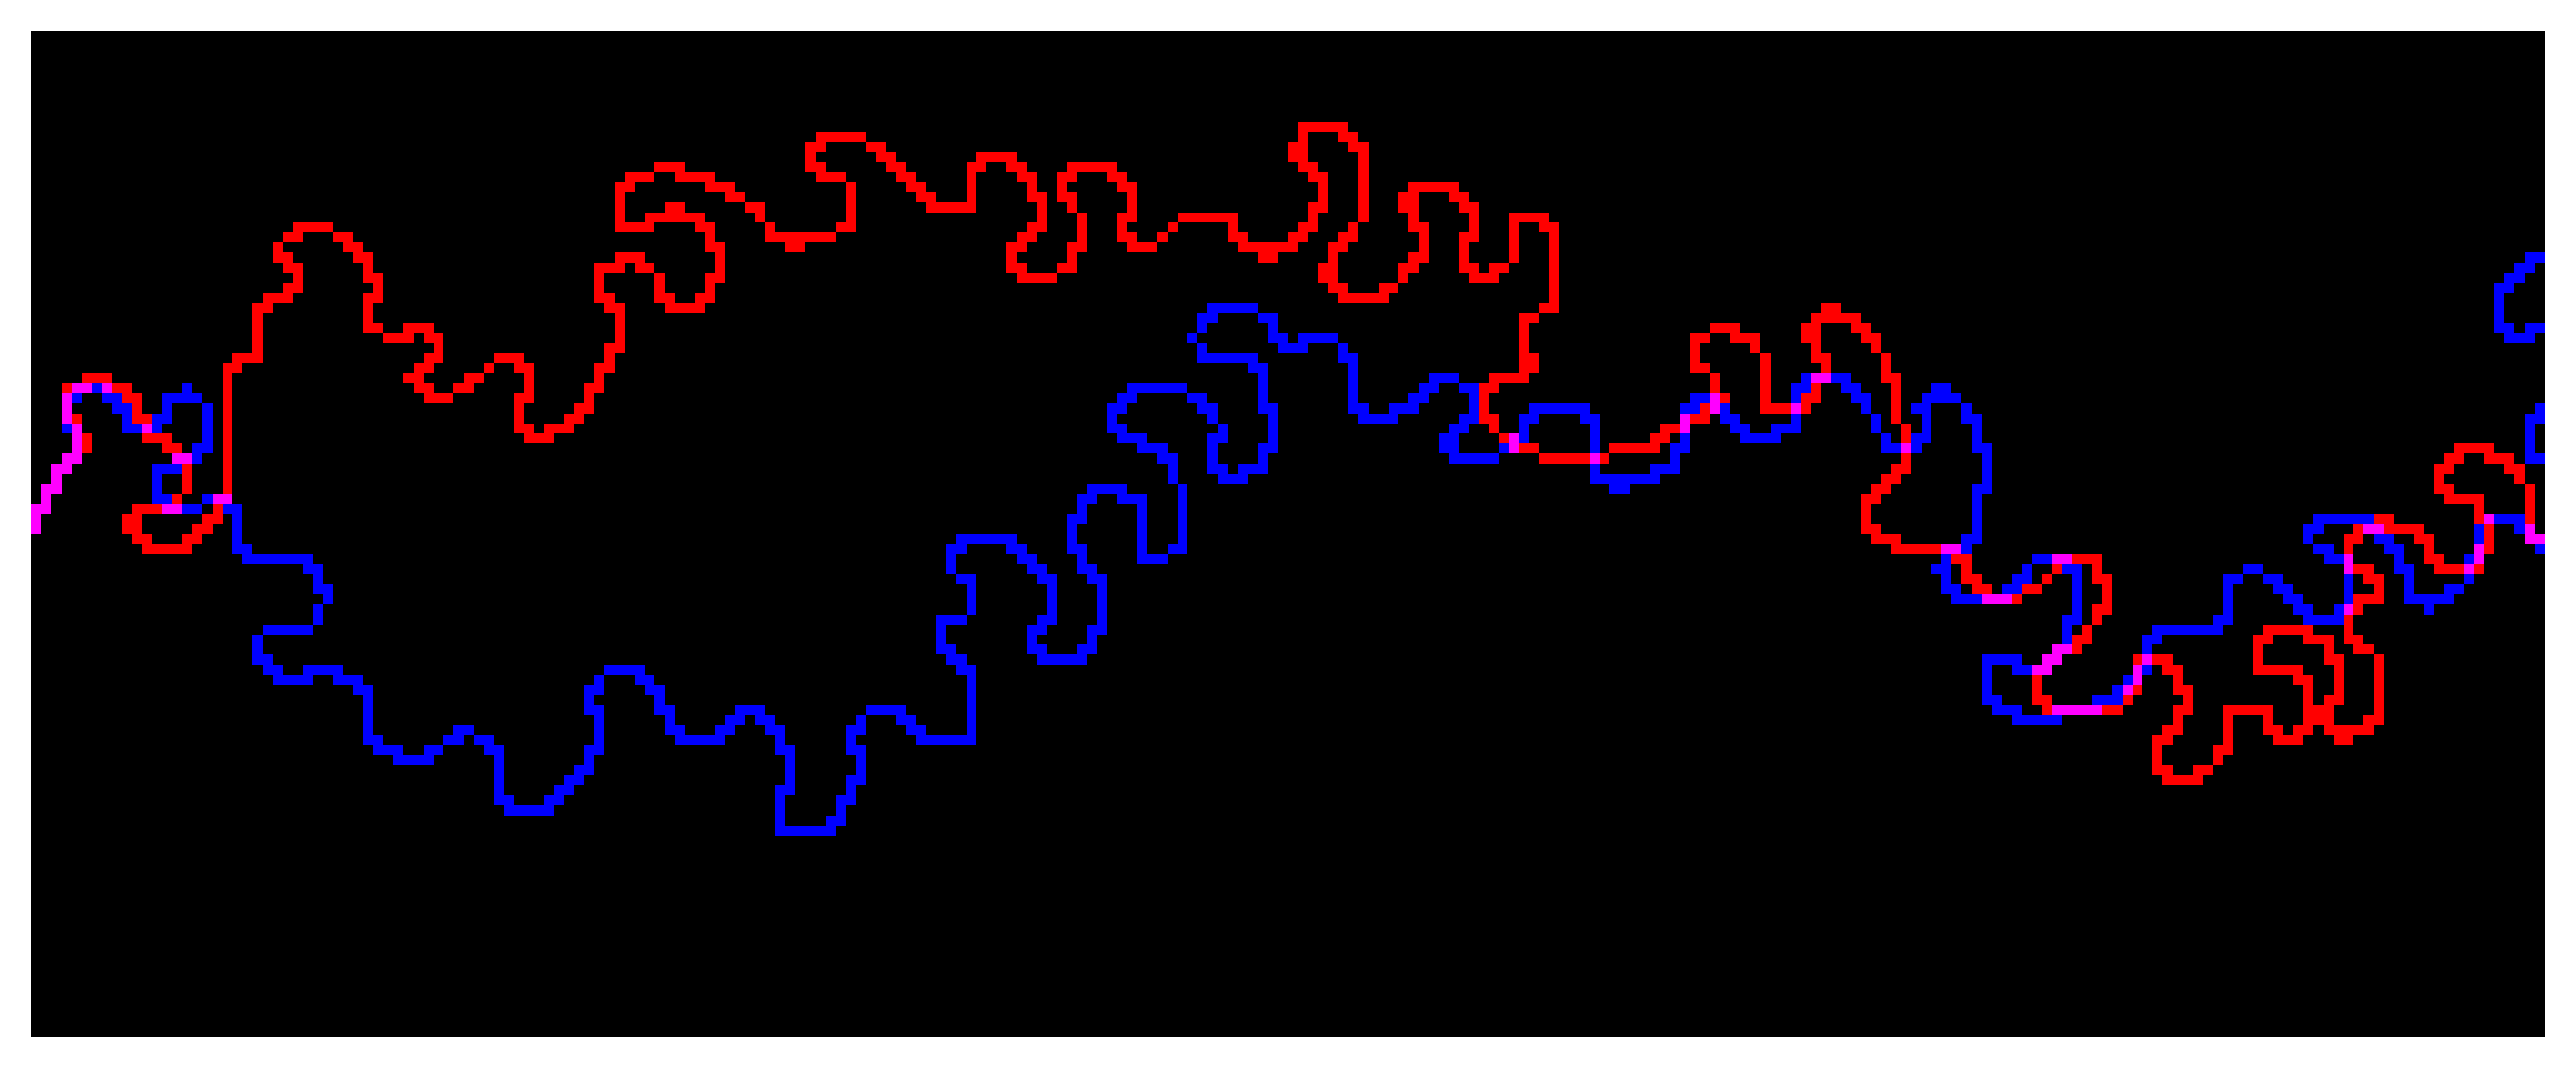

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import meanderpy as mp

plt.rcParams["figure.dpi"] = 600

def run_meander_simulation(freq_multiplier: float,
                           amplitude: float,
                           *,
                           n_perturb: int = 0,
                           perturb_magnitude: float = 0.0,
                           nit: int = 501,
                           saved_ts: int = 1,
                           random_seed: int | None = None):
    W, D = 50.0, 1.0
    depths = D * np.ones(nit)
    pad, deltas, crdist = 0, 50.0, 5 * W
    Cfs = 0.0065 * np.ones(nit)
    kl = 500.0 / (365*24*60*60.0)
    kv = 1.0e-12
    dt = 0.2 * 0.5 * 365*24*60*60.0
    dens = 1000
    t1 = t2 = t3 = aggr = 0

    x = np.linspace(0.1, 10_000, 1500)
    y = (amplitude * 100.0) * np.sin(freq_multiplier * np.pi * x / 10_000.0)
    if n_perturb and perturb_magnitude:
        y[len(x)//2] += perturb_magnitude
    z = np.zeros_like(x)

    ch  = mp.Channel(x, y, z, W, depths[0])
    chb = mp.ChannelBelt([ch], [], [0.0], [])
    chb.migrate(nit, saved_ts, deltas, pad, crdist, depths, Cfs, kl, kv, dt, dens, t1, t2, t3, aggr)
    return chb

freq, A = 30.0, 3.0
dY = 1e-10
chb_ref   = run_meander_simulation(freq, A)
chb_pert  = run_meander_simulation(freq, A, n_perturb=1, perturb_magnitude=dY)

x_min, x_max, y_min, y_max = 0, 10_000, -2000, 2000
rows = 100
cols = int(round(rows * (x_max - x_min) / (y_max - y_min)))
extent = (x_min, x_max, y_min, y_max)
timestep = 300

def rasterize_to_binary_mask(x, y, grid_shape, extent, n_seg=10):
    rows, cols = grid_shape
    x_min, x_max, y_min, y_max = extent
    dx, dy = (x_max - x_min) / cols, (y_max - y_min) / rows
    canvas = np.zeros((rows, cols), dtype=np.uint8)
    if len(x) < 2: return canvas
    xr = []; yr = []
    for x0, y0, x1, y1 in zip(x[:-1], y[:-1], x[1:], y[1:]):
        t = np.linspace(0, 1, n_seg)
        xr.append(x0 + t*(x1 - x0))
        yr.append(y0 + t*(y1 - y0))
    xs = np.concatenate([x] + xr)
    ys = np.concatenate([y] + yr)
    c = ((xs - x_min) / dx).astype(int)
    r = ((ys - y_min) / dy).astype(int)
    m = (0 <= c) & (c < cols) & (0 <= r) & (r < rows)
    canvas[r[m], c[m]] = 1
    return canvas

ref = chb_ref.channels[timestep];    pert = chb_pert.channels[timestep]
grid_shape = (rows, cols)
ref_mask  = rasterize_to_binary_mask(ref.x,  ref.y,  grid_shape, extent)
pert_mask = rasterize_to_binary_mask(pert.x, pert.y, grid_shape, extent)

rgb = np.zeros((rows, cols, 3), dtype=np.uint8)
rgb[..., 0] = ref_mask * 255
rgb[..., 2] = pert_mask * 255

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(rgb, origin='lower', extent=[x_min, x_max, y_min, y_max], aspect='equal')
ax.set_xticks([x_min, x_max]); ax.set_yticks([y_min, y_max])
ax.axis("off")
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()